In [1]:
# ============================================================================
# 1. IMPORTS AND SETUP
# ============================================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')


Using device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [ ]:
# ============================================================================
# 2. CONFIGURATION
# ============================================================================

class Config:
    # Paths
    TRAIN_DIR = r"E:\LamMinhTri\Tai_Lieu_Hoc_Tap\2026_Semester 1\DAT301m\The_Emotion_Explorers\Mood-and-Attention-Monitoring-in-Online-Classrooms\dataset\train"
    TEST_DIR = r"E:\LamMinhTri\Tai_Lieu_Hoc_Tap\2026_Semester 1\DAT301m\The_Emotion_Explorers\Mood-and-Attention-Monitoring-in-Online-Classrooms\dataset\test"
    
    # Classes
    CLASSES = ['anger', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
    NUM_CLASSES = 7
    
    # Training parameters
    BATCH_SIZE = 64
    NUM_EPOCHS = 100
    LEARNING_RATE = 0.0001
    # LEARNING_RATE = 0.00001
    WEIGHT_DECAY = 1e-4
    
    # Image parameters
    IMG_SIZE = 96
    
    # Model parameters
    DROPOUT = 0.5
    
    # Early stopping
    PATIENCE = 10
    
config = Config()


In [3]:
# ============================================================================
# 3. CUSTOM DATASET CLASS
# ============================================================================

class EmotionDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.images = []
        self.labels = []
        
        # Load all images and labels
        for idx, emotion in enumerate(config.CLASSES):
            emotion_path = os.path.join(root_dir, emotion)
            if os.path.exists(emotion_path):
                for img_name in os.listdir(emotion_path):
                    if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                        self.images.append(os.path.join(emotion_path, img_name))
                        self.labels.append(idx)
        
        print(f'Loaded {len(self.images)} images from {root_dir}')
        
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img_path = self.images[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

In [4]:
# ============================================================================
# 4. DATA AUGMENTATION AND TRANSFORMS
# ============================================================================

# Training transforms with augmentation
train_transforms = transforms.Compose([
    transforms.Resize((config.IMG_SIZE, config.IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225])
])

# Test transforms without augmentation
test_transforms = transforms.Compose([
    transforms.Resize((config.IMG_SIZE, config.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225])
])

# Create datasets
train_dataset = EmotionDataset(config.TRAIN_DIR, transform=train_transforms)
test_dataset = EmotionDataset(config.TEST_DIR, transform=test_transforms)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, 
                         shuffle=True, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=config.BATCH_SIZE, 
                        shuffle=False, num_workers=0, pin_memory=True)

print(f'\nTrain batches: {len(train_loader)}')
print(f'Test batches: {len(test_loader)}')

Loaded 9275 images from E:\LamMinhTri\Tai_Lieu_Hoc_Tap\2026_Semester 1\DAT301m\The_Emotion_Explorers\Mood-and-Attention-Monitoring-in-Online-Classrooms\dataset\train
Loaded 8771 images from E:\LamMinhTri\Tai_Lieu_Hoc_Tap\2026_Semester 1\DAT301m\The_Emotion_Explorers\Mood-and-Attention-Monitoring-in-Online-Classrooms\dataset\test

Train batches: 145
Test batches: 138


In [5]:
# ============================================================================
# 5. MODEL ARCHITECTURES
# ============================================================================

class ResNet18Emotion(nn.Module):
    def __init__(self, num_classes=7, dropout=0.5):
        super(ResNet18Emotion, self).__init__()
        self.resnet = models.resnet18(pretrained=True)
        
        # Freeze early layers
        for param in list(self.resnet.parameters())[:-20]:
            param.requires_grad = False
        
        # Replace final layer
        num_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(num_features, 512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes)
        )
    
    def forward(self, x):
        return self.resnet(x)


class MobileNetV2Emotion(nn.Module):
    def __init__(self, num_classes=7, dropout=0.5):
        super(MobileNetV2Emotion, self).__init__()
        self.mobilenet = models.mobilenet_v2(pretrained=True)
        
        # Freeze early layers
        for param in list(self.mobilenet.parameters())[:-30]:
            param.requires_grad = False
        
        # Replace classifier
        num_features = self.mobilenet.classifier[1].in_features
        self.mobilenet.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(num_features, 512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes)
        )
    
    def forward(self, x):
        return self.mobilenet(x)


class EfficientNetB0Emotion(nn.Module):
    def __init__(self, num_classes=7, dropout=0.5):
        super(EfficientNetB0Emotion, self).__init__()
        self.efficientnet = models.efficientnet_b0(pretrained=True)
        
        # Freeze early layers
        for param in list(self.efficientnet.parameters())[:-30]:
            param.requires_grad = False
        
        # Replace classifier
        num_features = self.efficientnet.classifier[1].in_features
        self.efficientnet.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(num_features, 512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes)
        )
    
    def forward(self, x):
        return self.efficientnet(x)


class EnsembleModel(nn.Module):
    def __init__(self, num_classes=7, dropout=0.5):
        super(EnsembleModel, self).__init__()
        
        self.resnet = ResNet18Emotion(num_classes, dropout)
        self.mobilenet = MobileNetV2Emotion(num_classes, dropout)
        self.efficientnet = EfficientNetB0Emotion(num_classes, dropout)
        
        # Learnable weights for ensemble
        self.weights = nn.Parameter(torch.ones(3) / 3)
        
    def forward(self, x):
        out1 = self.resnet(x)
        out2 = self.mobilenet(x)
        out3 = self.efficientnet(x)
        
        # Weighted average
        weights = torch.softmax(self.weights, dim=0)
        output = weights[0] * out1 + weights[1] * out2 + weights[2] * out3
        
        return output

# Initialize model
model = EnsembleModel(num_classes=config.NUM_CLASSES, dropout=config.DROPOUT)
model = model.to(device)

print(f'\nModel parameters: {sum(p.numel() for p in model.parameters()):,}')
print(f'Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')



Model parameters: 18,993,108
Trainable parameters: 13,436,920


In [6]:
# ============================================================================
# 6. LOSS FUNCTION AND OPTIMIZER
# ============================================================================

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=config.LEARNING_RATE, 
                        weight_decay=config.WEIGHT_DECAY)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', 
                                                  factor=0.5, patience=5, 
                                                  verbose=True)

In [7]:
# ============================================================================
# 7. TRAINING AND VALIDATION FUNCTIONS
# ============================================================================

def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    progress_bar = tqdm(dataloader, desc='Training')
    
    for inputs, labels in progress_bar:
        inputs, labels = inputs.to(device), labels.to(device)
        
        # Zero gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Statistics
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        # Update progress bar
        progress_bar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc': f'{100 * correct / total:.2f}%'
        })
    
    epoch_loss = running_loss / total
    epoch_acc = 100 * correct / total
    
    return epoch_loss, epoch_acc


def validate_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    progress_bar = tqdm(dataloader, desc='Validation')
    
    with torch.no_grad():
        for inputs, labels in progress_bar:
            inputs, labels = inputs.to(device), labels.to(device)
            
            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            # Statistics
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
            # Update progress bar
            progress_bar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'acc': f'{100 * correct / total:.2f}%'
            })
    
    epoch_loss = running_loss / total
    epoch_acc = 100 * correct / total
    
    return epoch_loss, epoch_acc, all_preds, all_labels

In [8]:
# ============================================================================
# 8. TRAINING LOOP WITH EARLY STOPPING
# ============================================================================

def train_model(model, train_loader, test_loader, criterion, optimizer, 
                scheduler, num_epochs, patience, device):
    
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }
    
    best_val_acc = 0.0
    best_model_weights = None
    epochs_no_improve = 0
    
    for epoch in range(num_epochs):
        print(f'\n{"="*60}')
        print(f'Epoch {epoch+1}/{num_epochs}')
        print(f'{"="*60}')
        
        # Train
        train_loss, train_acc = train_epoch(model, train_loader, criterion, 
                                           optimizer, device)
        
        # Validate
        val_loss, val_acc, _, _ = validate_epoch(model, test_loader, criterion, device)
        
        # Update learning rate
        scheduler.step(val_acc)
        
        # Save history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        # Print epoch summary
        print(f'\nEpoch Summary:')
        print(f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%')
        print(f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%')
        
        # Early stopping and model checkpointing
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_weights = model.state_dict().copy()
            epochs_no_improve = 0
            torch.save(model.state_dict(), 'best_emotion_model.pth')
            print(f'✓ Best model saved! (Val Acc: {val_acc:.2f}%)')
        else:
            epochs_no_improve += 1
            print(f'No improvement for {epochs_no_improve} epoch(s)')
            
        if epochs_no_improve >= patience:
            print(f'\nEarly stopping triggered after {epoch+1} epochs')
            break
    
    # Load best model
    model.load_state_dict(best_model_weights)
    
    return model, history, best_val_acc

In [9]:
# Train the model
print('Starting training...\n')
model, history, best_val_acc = train_model(
    model, train_loader, test_loader, criterion, optimizer, 
    scheduler, config.NUM_EPOCHS, config.PATIENCE, device
)

print(f'\n{"="*60}')
print(f'Training completed!')
print(f'Best Validation Accuracy: {best_val_acc:.2f}%')
print(f'{"="*60}')

Starting training...


Epoch 1/100


Validation: 100%|██████████| 138/138 [01:54<00:00,  1.20it/s, loss=1.9224, acc=24.66%]



Epoch Summary:
Train Loss: 1.9535 | Train Acc: 16.05%
Val Loss: 1.9093 | Val Acc: 24.66%
✓ Best model saved! (Val Acc: 24.66%)

Epoch 2/100


Validation: 100%|██████████| 138/138 [00:10<00:00, 13.36it/s, loss=1.8286, acc=29.38%]



Epoch Summary:
Train Loss: 1.9130 | Train Acc: 19.95%
Val Loss: 1.8641 | Val Acc: 29.38%
✓ Best model saved! (Val Acc: 29.38%)

Epoch 3/100


...


Epoch Summary:
Train Loss: 0.8809 | Train Acc: 66.29%
Val Loss: 1.2869 | Val Acc: 55.03%
✓ Best model saved! (Val Acc: 55.03%)

Epoch 99/100


Validation: 100%|██████████| 138/138 [00:09<00:00, 14.83it/s, loss=0.1090, acc=54.70%]



Epoch Summary:
Train Loss: 0.8713 | Train Acc: 66.61%
Val Loss: 1.2944 | Val Acc: 54.70%
No improvement for 1 epoch(s)

Epoch 100/100


Validation: 100%|██████████| 138/138 [00:09<00:00, 15.15it/s, loss=0.1509, acc=54.91%]


Epoch Summary:
Train Loss: 0.8773 | Train Acc: 66.10%
Val Loss: 1.2973 | Val Acc: 54.91%
No improvement for 2 epoch(s)

Training completed!
Best Validation Accuracy: 55.03%


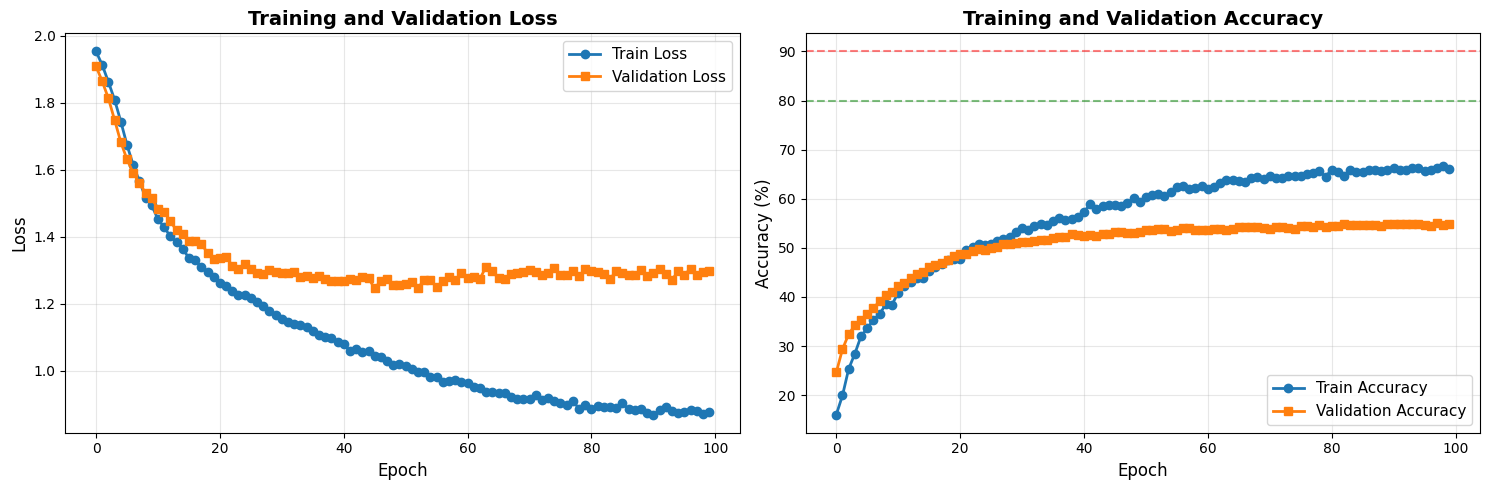

In [10]:
# ============================================================================
# 9. VISUALIZATION - TRAINING HISTORY
# ============================================================================

def plot_training_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Plot loss
    axes[0].plot(history['train_loss'], label='Train Loss', linewidth=2, marker='o')
    axes[0].plot(history['val_loss'], label='Validation Loss', linewidth=2, marker='s')
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)
    
    # Plot accuracy
    axes[1].plot(history['train_acc'], label='Train Accuracy', linewidth=2, marker='o')
    axes[1].plot(history['val_acc'], label='Validation Accuracy', linewidth=2, marker='s')
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Accuracy (%)', fontsize=12)
    axes[1].set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)
    axes[1].axhline(y=80, color='g', linestyle='--', label='80% Target', alpha=0.5)
    axes[1].axhline(y=90, color='r', linestyle='--', label='90% Target', alpha=0.5)
    
    plt.tight_layout()
    plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_training_history(history)

In [11]:
# ============================================================================
# 10. FINAL EVALUATION
# ============================================================================

def evaluate_model(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc='Evaluating'):
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    return np.array(all_preds), np.array(all_labels)

# Get predictions
print('Evaluating model on test set...')
predictions, true_labels = evaluate_model(model, test_loader, device)

# Calculate accuracy
test_accuracy = accuracy_score(true_labels, predictions) * 100
print(f'\nFinal Test Accuracy: {test_accuracy:.2f}%')

# Classification report
print('\nClassification Report:')
print(classification_report(true_labels, predictions, 
                          target_names=config.CLASSES, digits=4))

Evaluating model on test set...


Evaluating: 100%|██████████| 138/138 [00:08<00:00, 15.36it/s]


Final Test Accuracy: 54.91%

Classification Report:
              precision    recall  f1-score   support

       anger     0.5069    0.4693    0.4874      1253
     disgust     0.4690    0.4709    0.4699      1253
        fear     0.5149    0.4549    0.4831      1253
       happy     0.7369    0.8516    0.7901      1253
     neutral     0.6191    0.7614    0.6829      1253
         sad     0.4786    0.5092    0.4934      1253
    surprise     0.4426    0.3264    0.3757      1253

    accuracy                         0.5491      8771
   macro avg     0.5383    0.5491    0.5404      8771
weighted avg     0.5383    0.5491    0.5404      8771



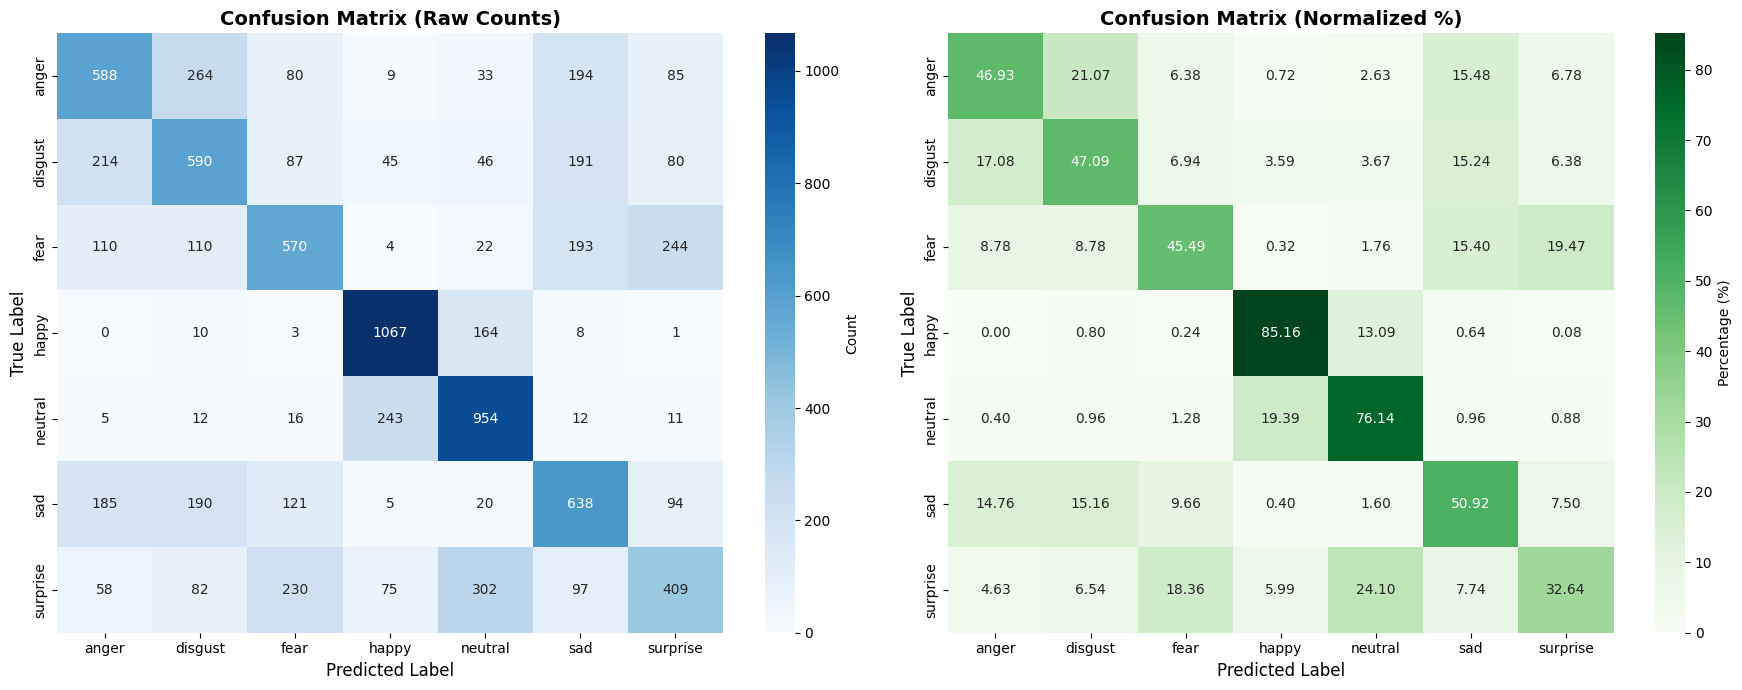

In [12]:
# ============================================================================
# 11. CONFUSION MATRIX VISUALIZATION
# ============================================================================

def plot_confusion_matrix(y_true, y_pred, classes):
    cm = confusion_matrix(y_true, y_pred)
    
    # Normalize confusion matrix
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    
    # Raw confusion matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes, 
                ax=axes[0], cbar_kws={'label': 'Count'})
    axes[0].set_title('Confusion Matrix (Raw Counts)', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('True Label', fontsize=12)
    axes[0].set_xlabel('Predicted Label', fontsize=12)
    
    # Normalized confusion matrix
    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Greens', 
                xticklabels=classes, yticklabels=classes, 
                ax=axes[1], cbar_kws={'label': 'Percentage (%)'})
    axes[1].set_title('Confusion Matrix (Normalized %)', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('True Label', fontsize=12)
    axes[1].set_xlabel('Predicted Label', fontsize=12)
    
    plt.tight_layout()
    plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_confusion_matrix(true_labels, predictions, config.CLASSES)

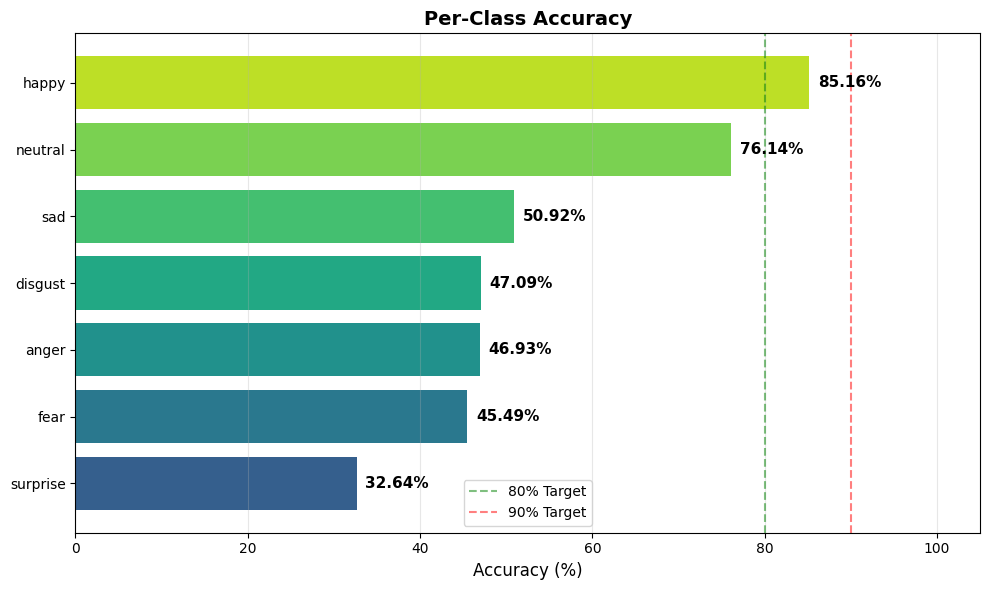


Per-Class Accuracy:
surprise  :  32.64%
fear      :  45.49%
anger     :  46.93%
disgust   :  47.09%
sad       :  50.92%
neutral   :  76.14%
happy     :  85.16%


In [13]:
# ============================================================================
# 12. PER-CLASS ACCURACY VISUALIZATION
# ============================================================================

def plot_per_class_accuracy(y_true, y_pred, classes):
    cm = confusion_matrix(y_true, y_pred)
    per_class_acc = cm.diagonal() / cm.sum(axis=1) * 100
    
    # Create DataFrame for better visualization
    acc_df = pd.DataFrame({
        'Emotion': classes,
        'Accuracy (%)': per_class_acc
    }).sort_values('Accuracy (%)', ascending=True)
    
    # Plot
    plt.figure(figsize=(10, 6))
    bars = plt.barh(acc_df['Emotion'], acc_df['Accuracy (%)'], 
                    color=plt.cm.viridis(np.linspace(0.3, 0.9, len(classes))))
    
    # Add value labels on bars
    for i, (bar, val) in enumerate(zip(bars, acc_df['Accuracy (%)'])):
        plt.text(val + 1, bar.get_y() + bar.get_height()/2, 
                f'{val:.2f}%', va='center', fontsize=11, fontweight='bold')
    
    plt.xlabel('Accuracy (%)', fontsize=12)
    plt.title('Per-Class Accuracy', fontsize=14, fontweight='bold')
    plt.xlim(0, 105)
    plt.axvline(x=80, color='green', linestyle='--', alpha=0.5, label='80% Target')
    plt.axvline(x=90, color='red', linestyle='--', alpha=0.5, label='90% Target')
    plt.legend()
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('per_class_accuracy.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print('\nPer-Class Accuracy:')
    for emotion, acc in zip(acc_df['Emotion'], acc_df['Accuracy (%)']):
        print(f'{emotion:10s}: {acc:6.2f}%')

plot_per_class_accuracy(true_labels, predictions, config.CLASSES)

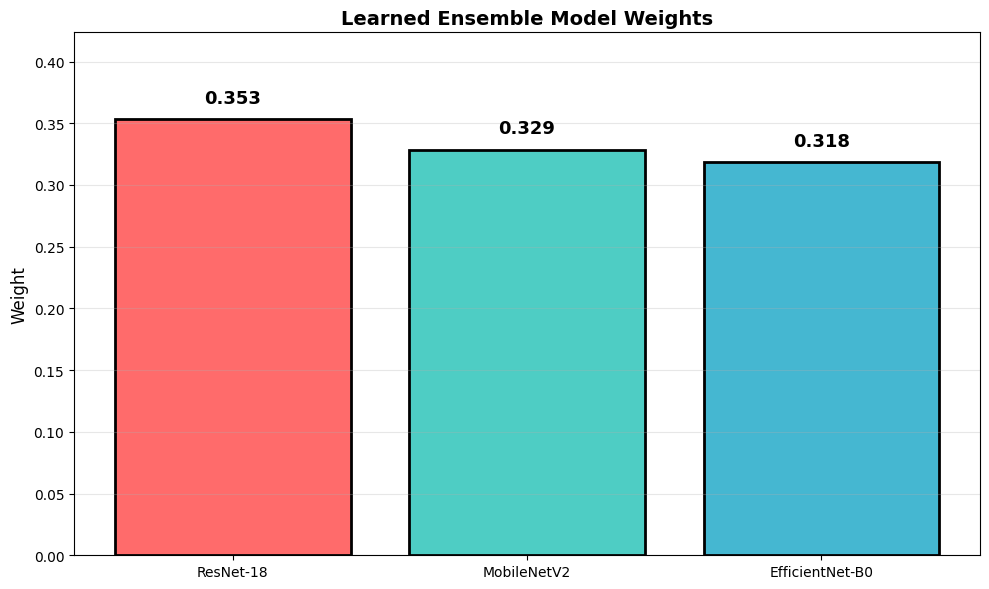

Ensemble Weights:
ResNet-18           : 0.3531
MobileNetV2         : 0.3287
EfficientNet-B0     : 0.3182


In [14]:
# ============================================================================
# 13. MODEL ENSEMBLE WEIGHTS VISUALIZATION
# ============================================================================

def visualize_ensemble_weights(model):
    weights = torch.softmax(model.weights, dim=0).detach().cpu().numpy()
    model_names = ['ResNet-18', 'MobileNetV2', 'EfficientNet-B0']
    
    plt.figure(figsize=(10, 6))
    bars = plt.bar(model_names, weights, color=['#FF6B6B', '#4ECDC4', '#45B7D1'], 
                   edgecolor='black', linewidth=2)
    
    # Add value labels
    for bar, weight in zip(bars, weights):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{weight:.3f}',
                ha='center', va='bottom', fontsize=13, fontweight='bold')
    
    plt.ylabel('Weight', fontsize=12)
    plt.title('Learned Ensemble Model Weights', fontsize=14, fontweight='bold')
    plt.ylim(0, max(weights) * 1.2)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('ensemble_weights.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print('Ensemble Weights:')
    for name, weight in zip(model_names, weights):
        print(f'{name:20s}: {weight:.4f}')

visualize_ensemble_weights(model)

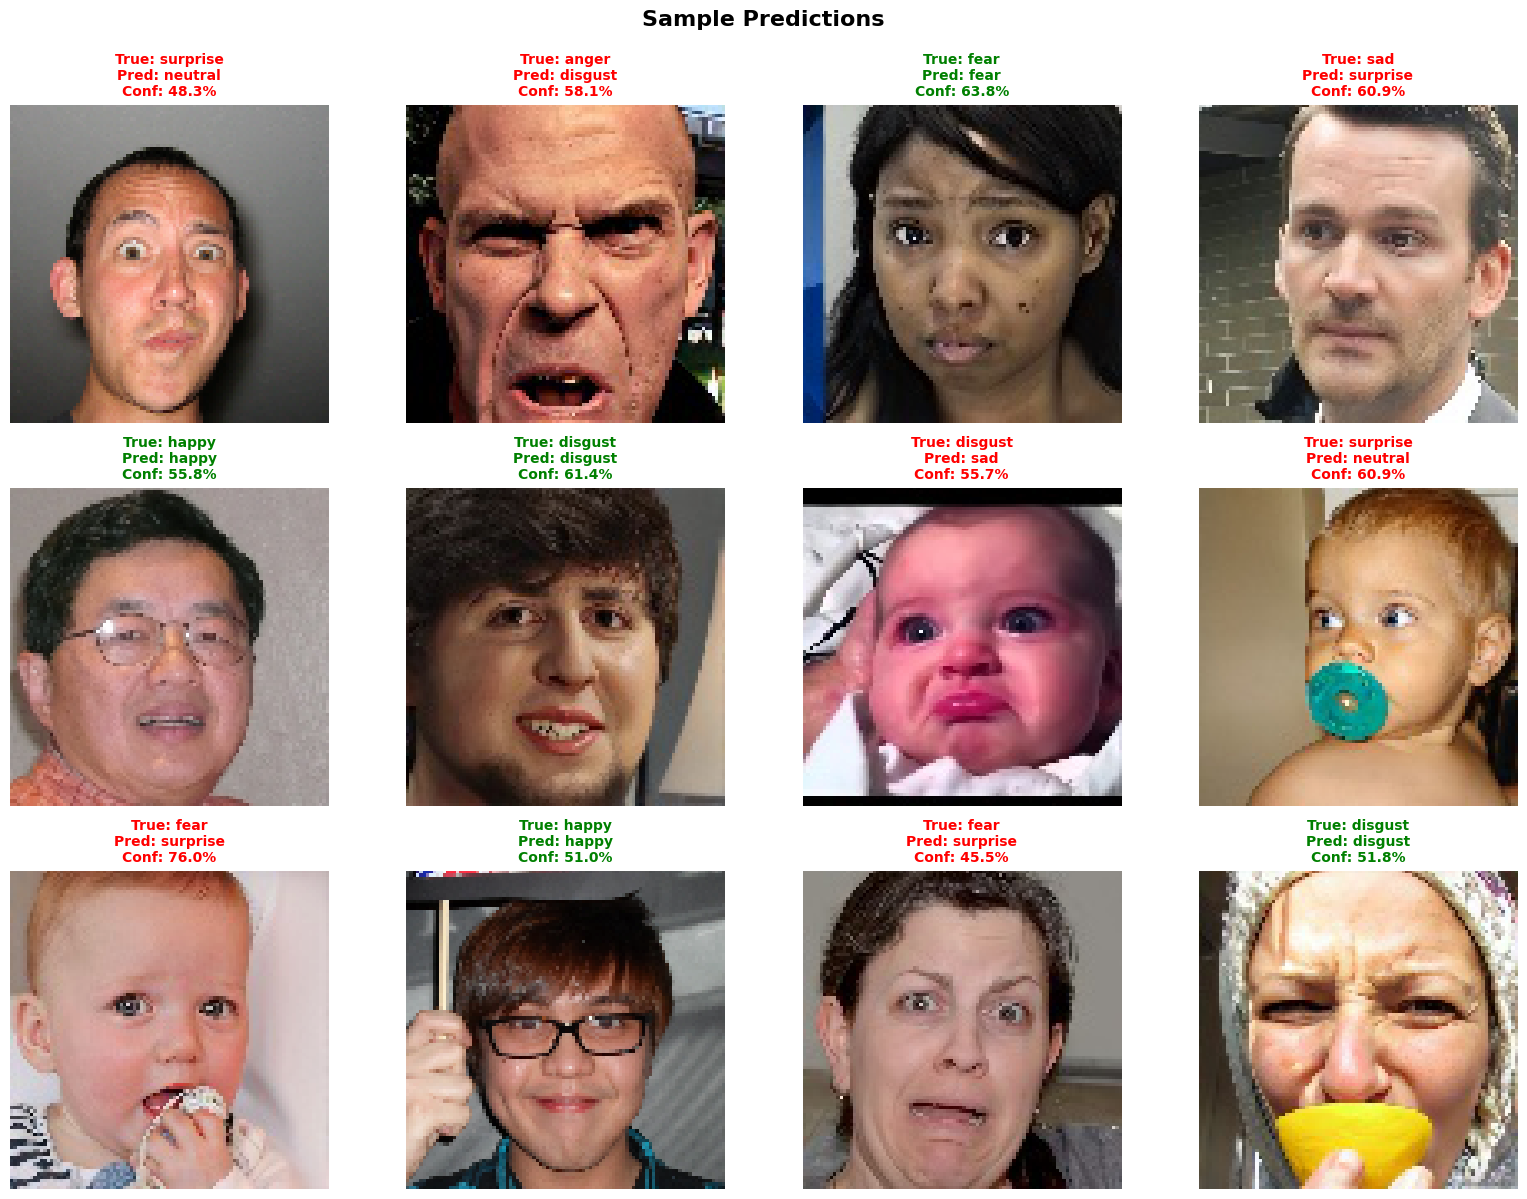

In [15]:
# ============================================================================
# 14. PREDICTION EXAMPLES VISUALIZATION
# ============================================================================

def visualize_predictions(model, dataset, device, num_samples=12):
    model.eval()
    
    # Get random samples
    indices = np.random.choice(len(dataset), num_samples, replace=False)
    
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    axes = axes.ravel()
    
    for idx, sample_idx in enumerate(indices):
        image, true_label = dataset[sample_idx]
        
        # Make prediction
        with torch.no_grad():
            image_batch = image.unsqueeze(0).to(device)
            output = model(image_batch)
            probabilities = torch.softmax(output, dim=1)
            confidence, predicted = torch.max(probabilities, 1)
            
        # Denormalize image for display
        img = image.cpu().numpy().transpose(1, 2, 0)
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)
        
        # Plot
        axes[idx].imshow(img)
        axes[idx].axis('off')
        
        true_emotion = config.CLASSES[true_label]
        pred_emotion = config.CLASSES[predicted.item()]
        conf = confidence.item() * 100
        
        color = 'green' if true_label == predicted.item() else 'red'
        title = f'True: {true_emotion}\nPred: {pred_emotion}\nConf: {conf:.1f}%'
        axes[idx].set_title(title, fontsize=10, color=color, fontweight='bold')
    
    plt.suptitle('Sample Predictions', fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.savefig('prediction_examples.png', dpi=300, bbox_inches='tight')
    plt.show()

visualize_predictions(model, test_dataset, device, num_samples=12)

In [16]:
# ============================================================================
# 15. LEARNING RATE HISTORY (if using scheduler with history)
# ============================================================================

def plot_learning_rates(optimizer, history):
    """Plot learning rate changes during training"""
    lr_history = []
    
    # If you want to track LR, add this in training loop:
    # lr_history.append(optimizer.param_groups[0]['lr'])
    
    # For now, let's create a simple visualization showing final LR
    current_lr = optimizer.param_groups[0]['lr']
    
    print(f'\nFinal Learning Rate: {current_lr:.6f}')
    print(f'Initial Learning Rate: {config.LEARNING_RATE:.6f}')
    print(f'Reduction Factor: {config.LEARNING_RATE / current_lr:.2f}x')

In [17]:
# ============================================================================
# 16. SAVE FINAL RESULTS SUMMARY
# ============================================================================

def save_results_summary(history, test_accuracy, best_val_acc):
    summary = {
        'Model': 'Ensemble (ResNet-18 + MobileNetV2 + EfficientNet-B0)',
        'Best Validation Accuracy': f'{best_val_acc:.2f}%',
        'Final Test Accuracy': f'{test_accuracy:.2f}%',
        'Total Epochs': len(history['train_acc']),
        'Best Train Accuracy': f"{max(history['train_acc']):.2f}%",
        'Final Train Loss': f"{history['train_loss'][-1]:.4f}",
        'Final Val Loss': f"{history['val_loss'][-1]:.4f}",
        'Target Range': '80-90%',
        'Target Achieved': 'Yes' if 80 <= test_accuracy <= 90 else 'No'
    }
    
    print('\n' + '='*60)
    print('FINAL RESULTS SUMMARY')
    print('='*60)
    for key, value in summary.items():
        print(f'{key:30s}: {value}')
    print('='*60)
    
    # Save to file
    with open('results_summary.txt', 'w') as f:
        for key, value in summary.items():
            f.write(f'{key}: {value}\n')
    
    return summary

results = save_results_summary(history, test_accuracy, best_val_acc)


FINAL RESULTS SUMMARY
Model                         : Ensemble (ResNet-18 + MobileNetV2 + EfficientNet-B0)
Best Validation Accuracy      : 55.03%
Final Test Accuracy           : 54.91%
Total Epochs                  : 100
Best Train Accuracy           : 66.61%
Final Train Loss              : 0.8773
Final Val Loss                : 1.2973
Target Range                  : 80-90%
Target Achieved               : No


In [18]:
# # ============================================================================
# # 17. INFERENCE FUNCTION FOR NEW IMAGES
# # ============================================================================

# def predict_emotion(model, image_path, device):
#     """Predict emotion for a single image"""
#     model.eval()
    
#     # Load and preprocess image
#     image = Image.open(image_path).convert('RGB')
#     transform = test_transforms
#     image_tensor = transform(image).unsqueeze(0).to(device)
    
#     # Predict
#     with torch.no_grad():
#         output = model(image_tensor)
#         probabilities = torch.softmax(output, dim=1)[0]
#         confidence, predicted = torch.max(probabilities, 0)
    
#     # Get results
#     emotion = config.CLASSES[predicted.item()]
#     conf = confidence.item() * 100
    
#     # Get all probabilities
#     all_probs = {config.CLASSES[i]: probabilities[i].item() * 100 
#                  for i in range(len(config.CLASSES))}
    
#     return emotion, conf, all_probs

# # Example usage:
# # emotion, confidence, all_probs = predict_emotion(model, 'path/to/image.jpg', device)
# # print(f'Predicted Emotion: {emotion}')
# # print(f'Confidence: {confidence:.2f}%')
# # print('\nAll Probabilities:')
# # for emo, prob in sorted(all_probs.items(), key=lambda x: x[1], reverse=True):
# #     print(f'{emo:10s}: {prob:6.2f}%')